<div style = "background-color:#1F3864; padding:25px; border-radius:8px;">
<h1 style="color:white; text-align:center; margin:0;"> Fuel Crisis Price Forecasting — Exploratory Data Analysis </h1>
<p style="color:#D9E2F3; text-align:center; margin-top:10px; font-size:15px;">
Exploring crude oil and gasoline price movements during the 2026 Iran War 
fuel crisis — trends, volatility, and correlations with crisis timeline 
events and public sentiment — before building the forecasting model.
</p>
</div>

## Overview

**Project:** Fuel Crisis Price Forecasting  
**Goal:** Forecast US gas and crude oil prices during the 2026 Iran War fuel 
crisis, using historical price data, crisis timeline events, and Reddit 
sentiment as features.  
**Repo:** [github.com/abdallahh07/fuel-crisis-price-forecasting](https://github.com/abdallahh07/fuel-crisis-price-forecasting)

## Data

Real, sourced data covering the crisis period (Jan–July 2026):
- `crude_oil_prices.csv` — daily WTI, Brent, and Henry Hub futures
- `us_gasoline_prices.csv` — weekly US retail gasoline/diesel prices by region
- `us_refinery_and_trade_weekly.csv` — refinery utilization and trade data
- `crisis_timeline.csv` — dated, cited timeline of crisis events
- `country_gas_price_comparison.csv` — cross-country pump price snapshot
- `reddit_sentiment.csv` — top crisis-related discussion posts

## Plan

1. **EDA** — explore price trends, volatility, and correlations between 
   crude oil, gasoline, and crisis timeline events
2. **Time-series diagnostics** — seasonality, stationarity, autocorrelation
3. **Feature engineering** — incorporate crisis events and sentiment as 
   features alongside price history
4. **Modeling** — build and evaluate a forecasting model
5. **Production structure** — config, pipeline, FastAPI service, Docker 
   (structure already scaffolded in the repo)

In [86]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

## Time-Series Analysis Tools

- **`pearsonr`** — tests linear correlation between two variables (e.g., crude 
  oil vs. gasoline prices), returning both correlation strength and 
  statistical significance.
- **`seasonal_decompose`** — splits each price series into trend, 
  seasonality, and residual components, to understand what's driving price 
  movement beyond the crisis shock itself.
- **`plot_acf` / `plot_pacf`** — autocorrelation diagnostics, showing how 
  strongly a price depends on its own recent past values. Used to inform 
  forecasting model choice and parameters.
- **`adfuller`** — Augmented Dickey-Fuller stationarity test. Checks whether 
  price series need transformation (e.g., differencing) before being used 
  in certain forecasting models.

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">1. Load the Data</h2>
</div>

In [87]:
crude_oil = pd.read_csv("../data/raw/crude_oil_prices.csv")
us_gasoline = pd.read_csv("../data/raw/us_gasoline_prices.csv")
refinery_trade = pd.read_csv("../data/raw/us_refinery_and_trade_weekly.csv")
crisis_timeline = pd.read_csv("../data/raw/crisis_timeline.csv")
country_comparison = pd.read_csv("../data/raw/country_gas_price_comparison.csv")
reddit_sentiment = pd.read_csv("../data/raw/reddit_sentiment.csv")

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">2. Review the Data Structure</h2>
</div>

In [88]:
print(crude_oil.shape)
print(us_gasoline.shape)
print(refinery_trade.shape)
print(crisis_timeline.shape)
print(country_comparison.shape)
print(reddit_sentiment.shape)

(126, 16)
(26, 40)
(26, 10)
(71, 6)
(170, 5)
(50, 6)


## Dataset Size Note

These are intentionally **short, real-world time series**, not large-scale 
transactional data:

| File | Rows | Granularity |
|---|---|---|
| `crude_oil_prices.csv` | 126 | Daily, ~6 months (Jan–Jul 2026) |
| `us_gasoline_prices.csv` | 26 | Weekly, same period |
| `us_refinery_and_trade_weekly.csv` | 26 | Weekly, same period |
| `crisis_timeline.csv` | 71 | Discrete dated events |
| `country_gas_price_comparison.csv` | 170 | One snapshot, per-country |
| `reddit_sentiment.csv` | 50 | Top posts only, not a full scrape |

This is expected and appropriate for the project — the data covers a 
genuinely bounded real-world event (a several-month crisis), collected at 
daily/weekly granularity rather than high-frequency transactional volume. 
Forecasting approaches here will rely more on the time-based structure 
(trend, seasonality, event timing) than on large sample size — standard 
large train/validation splitting used in other projects tonight won't 
apply the same way here.

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.1 Checking the data types</h3>
</div>

In [89]:
print(crude_oil.dtypes)

date                   object
wti_crude_close       float64
wti_crude_high        float64
wti_crude_low         float64
wti_crude_open        float64
wti_crude_volume        int64
brent_crude_close     float64
brent_crude_high      float64
brent_crude_low       float64
brent_crude_open      float64
brent_crude_volume      int64
natural_gas_close     float64
natural_gas_high      float64
natural_gas_low       float64
natural_gas_open      float64
natural_gas_volume      int64
dtype: object


In [90]:
print(us_gasoline.dtypes)


date                                         object
us_regular_gasoline                         float64
east_coast_padd1_regular_gasoline           float64
new_england_padd1a_regular_gasoline         float64
central_atlantic_padd1b_regular_gasoline    float64
lower_atlantic_padd1c_regular_gasoline      float64
midwest_padd2_regular_gasoline              float64
gulf_coast_padd3_regular_gasoline           float64
rocky_mountain_padd4_regular_gasoline       float64
west_coast_padd5_regular_gasoline           float64
california_regular_gasoline                 float64
colorado_regular_gasoline                   float64
florida_regular_gasoline                    float64
massachusetts_regular_gasoline              float64
minnesota_regular_gasoline                  float64
new_york_state_regular_gasoline             float64
ohio_regular_gasoline                       float64
texas_regular_gasoline                      float64
washington_regular_gasoline                 float64
boston_ma_re

In [91]:
print(refinery_trade.dtypes)


date                                        object
refinery_utilization_pct                   float64
refinery_crude_inputs_kbd                    int64
refinery_gross_inputs_kbd                    int64
refinery_operable_capacity_kbd               int64
crude_oil_imports_kbd                        int64
crude_oil_exports_kbd                        int64
total_petroleum_product_imports_kbd          int64
total_petroleum_product_exports_kbd          int64
net_total_crude_and_product_imports_kbd      int64
dtype: object


In [92]:
print(crisis_timeline.dtypes)

date           object
region         object
event          object
description    object
source_name    object
source_url     object
dtype: object


In [93]:
print(country_comparison.dtypes)


country                    object
gasoline_usd_per_liter    float64
diesel_usd_per_liter      float64
update_frequency           object
data_date                  object
dtype: object


In [94]:
print(reddit_sentiment.dtypes)

subreddit       object
title           object
score            int64
num_comments     int64
posted_utc      object
permalink       object
dtype: object


<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.2 Checking for null values</h3>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.2 Checking For Null Values</h3>
</div>

In [95]:
print("crude_oil:\n", crude_oil.isna().sum())
print("\nus_gasoline:\n", us_gasoline.isna().sum())
print("\nrefinery_trade:\n", refinery_trade.isna().sum())
print("\ncrisis_timeline:\n", crisis_timeline.isna().sum())
print("\ncountry_comparison:\n", country_comparison.isna().sum())
print("\nreddit_sentiment:\n", reddit_sentiment.isna().sum())

crude_oil:
 date                  0
wti_crude_close       0
wti_crude_high        0
wti_crude_low         0
wti_crude_open        0
wti_crude_volume      0
brent_crude_close     0
brent_crude_high      0
brent_crude_low       0
brent_crude_open      0
brent_crude_volume    0
natural_gas_close     0
natural_gas_high      0
natural_gas_low       0
natural_gas_open      0
natural_gas_volume    0
dtype: int64

us_gasoline:
 date                                        0
us_regular_gasoline                         0
east_coast_padd1_regular_gasoline           0
new_england_padd1a_regular_gasoline         0
central_atlantic_padd1b_regular_gasoline    0
lower_atlantic_padd1c_regular_gasoline      0
midwest_padd2_regular_gasoline              0
gulf_coast_padd3_regular_gasoline           0
rocky_mountain_padd4_regular_gasoline       0
west_coast_padd5_regular_gasoline           0
california_regular_gasoline                 0
colorado_regular_gasoline                   0
florida_regular_gasoline

## Missing Value Check

Checked `.isna().sum()` across all six datasets.

### Result: essentially clean data

- **5 of 6 files: zero missing values** — `crude_oil_prices`, 
  `us_gasoline_prices`, `us_refinery_and_trade_weekly`, `crisis_timeline`, 
  `reddit_sentiment`.
- **`country_gas_price_comparison.csv`: exactly 1 missing value** — 
  `diesel_usd_per_liter`, 1 row.

### No imputation required

This single missing value is **known, expected, and documented** — per the 
dataset's own README: *"Iraq has no diesel figure on the source site — left 
blank rather than filled in."* This was a deliberate data collection 
decision (not silently fabricating a number where the source had none), not 
a data quality issue to fix.

**Decision:** leave this value as-is. No imputation is applied — filling it 
in would fabricate a number that doesn't exist in the source data, 
contradicting the dataset's own stated principle of not estimating or 
interpolating missing figures. If Iraq's diesel price becomes relevant to 
a specific analysis later, it will be excluded from that calculation 
explicitly, rather than imputed.

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.3 Checking For Outliers</h3>
</div>

In [96]:
for i in data:
    cols = i.select_dtypes(include="number").columns
    q1 = i[cols].quantile(0.25)
    q3 = i[cols].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_mask = ((i[cols] < lower_bound) | (i[cols] > upper_bound)).any(axis=1)
    outliers = i[outlier_mask]
    print("Outliers found using IQR:", outliers.shape[0])


Outliers found using IQR: 20
Outliers found using IQR: 0
Outliers found using IQR: 1
Outliers found using IQR: 0
Outliers found using IQR: 5
Outliers found using IQR: 10


## Outlier Check (IQR Method)

Applied the IQR method (1.5 × IQR beyond Q1/Q3) across all numeric columns 
in each dataset.

### Results

| File | Outlier Rows |
|---|---|
| `crude_oil_prices` | 20 / 126 |
| `us_gasoline_prices` | 0 / 26 |
| `us_refinery_and_trade_weekly` | 1 / 26 |
| `crisis_timeline` | 0 / 71 |
| `country_gas_price_comparison` | 5 / 170 |
| `reddit_sentiment` | 10 / 50 |

### Interpretation

**1. `crude_oil_prices` — not real outliers, these ARE the crisis.**  
The 20 flagged rows are not data errors — they reflect the exceptional 
price surge caused by the closure of the Strait of Hormuz, through which 
almost 20% of world crude oil trade passes. This chokepoint closure 
directly drove WTI and Brent crude to their crisis peaks (WTI $112.95, 
Brent $118.35). These rows are the actual signal this project is built to 
capture and forecast — removing them would delete the exact event the 
model needs to learn from.

**2. `country_gas_price_comparison` — 5 outliers, likely tied to `diesel_usd_per_liter` and its correlation with crude oil.**  
These are likely countries whose diesel pricing diverges sharply from the 
norm — plausibly driven by the same underlying crude oil price shock 
(diesel is refined from crude, so extreme crude prices propagate into 
diesel pricing), or by domestic subsidy policy (e.g. Iran's heavily 
subsidized fuel pricing, noted in the dataset README). Worth investigating 
which specific countries these are before deciding how to treat them in 
feature engineering.

### Decision

**No outlier removal applied.** Every flagged value across these datasets 
represents either the crisis event itself or a genuinely informative 
extreme case (subsidy policy, price divergence) — not a data quality issue. 
Removing them would work directly against the project's goal of modeling 
the crisis's actual price impact.

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">3. Explanatory Data Analysis (EDA)</h2>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.1 Statistical Analysis</h3>
</div>

In [97]:
import os

def plot_histograms(dataframe, title, save_path=None):
    cols = dataframe.select_dtypes(include="number").columns
    n = len(cols)
    n_cols = 5
    n_rows = (n // n_cols) + (1 if n % n_cols else 0)
    
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
    ax = ax.flatten()
    
    for i, colum in enumerate(cols):
        ax[i].hist(dataframe[colum], bins=20)
        ax[i].set_title(colum, fontsize=9)
        
        mean_val = dataframe[colum].mean()
        std_val = dataframe[colum].std()
        
        ax[i].text(0.95, 0.95, f"mean:{mean_val:.2f}\nSTD:{std_val:.2f}",
                   transform=ax[i].transAxes, ha="right", va="top", fontsize=7)
    
    for j in range(i + 1, len(ax)):
        ax[j].set_visible(False)
    
    plt.suptitle(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    
    plt.show()

In [98]:
os.makedirs("../charts", exist_ok=True)


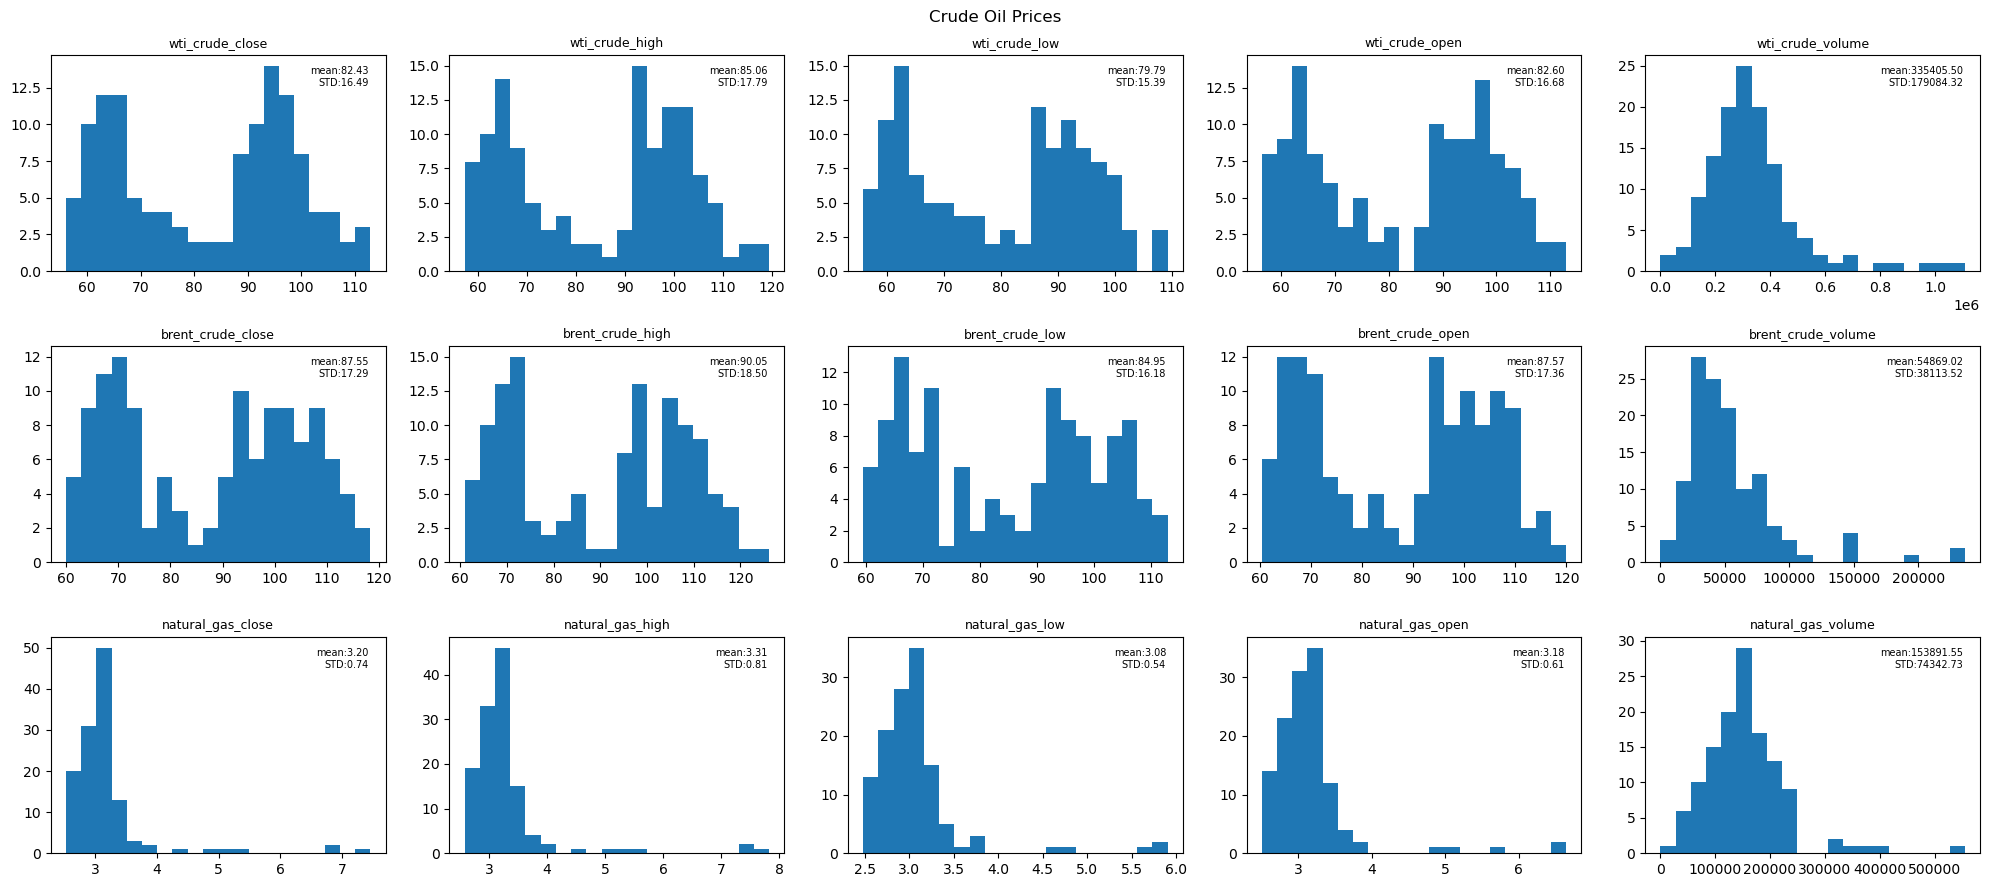

In [99]:
plot_histograms(crude_oil, "Crude Oil Prices", save_path="../charts/crude_oil_histograms.png")

## Crude Oil Price Distributions

### Clear bimodal pattern across WTI, Brent, and their sub-metrics

Nearly every price column (`wti_crude_close`, `wti_crude_high/low/open`, 
and the equivalent Brent columns) shows a **distinct two-peak (bimodal) 
distribution** — one cluster around $60-70, a gap, then a second cluster 
around $90-115. This is not noise — it's a direct visual signature of the 
crisis itself: prices sat in a stable pre-crisis range, then jumped to a 
new, much higher range during the Strait of Hormuz shock, with relatively 
few days spent transitioning between the two states.

### Volume columns behave differently

`wti_crude_volume` and `brent_crude_volume` are **right-skewed, unimodal** 
(single peak, long tail), unlike the price columns — trading volume doesn't 
show the same clean two-state pattern, suggesting volume spiked more 
gradually/variably rather than snapping between two distinct regimes the 
way price did.

### Natural gas behaves differently from oil

`natural_gas_close/high/low/open` are **strongly right-skewed with a tight 
main cluster around $3** and a long thin tail out to $7-8 — no clear 
bimodal pattern like crude oil. This suggests natural gas prices were less 
directly/uniformly affected by the crisis than crude oil was, or reacted 
with more day-to-day variability rather than a clean before/after price 
shift.

### Takeaway

The bimodal price pattern is strong, direct visual evidence of the crisis's 
structural impact on oil prices — this will likely be an important 
consideration for feature engineering (e.g., a binary "pre/post shock" 
indicator, or explicitly modeling the regime shift) and for model selection 
(a model needs to handle this discontinuity, not just a smooth trend).

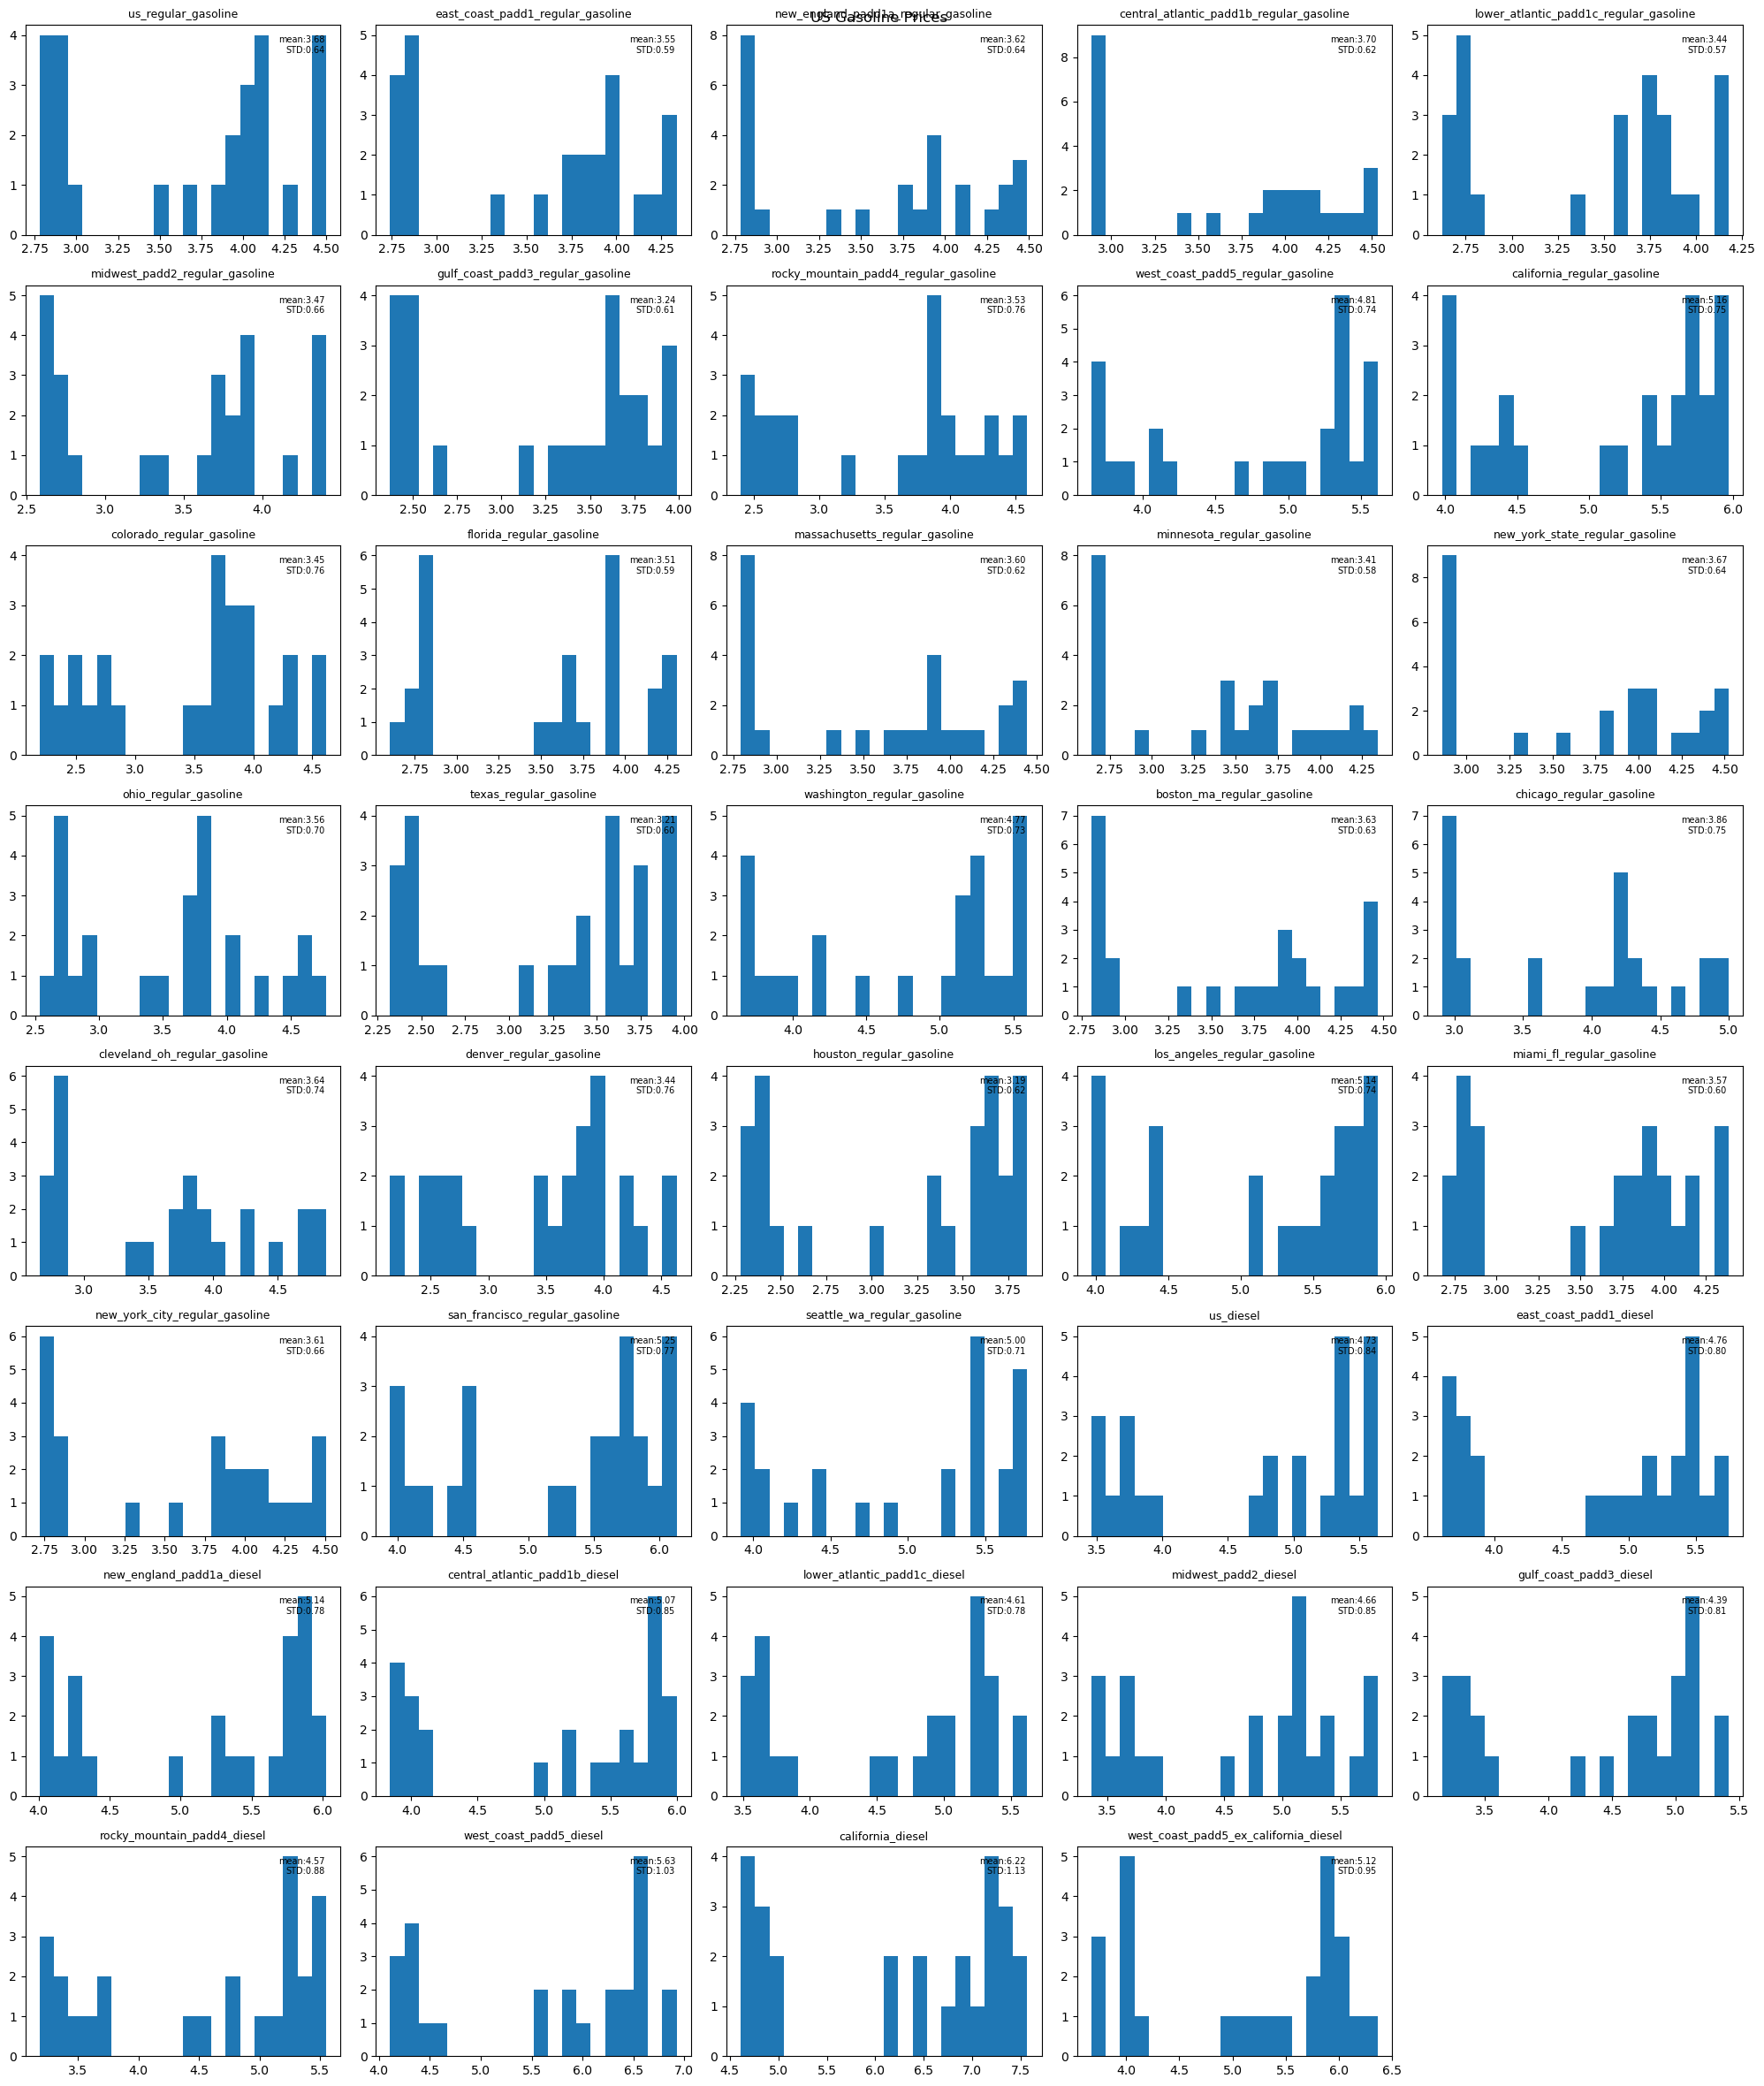

In [100]:
plot_histograms(us_gasoline, "US Gasoline Prices", save_path="../charts/us_gasoline_histograms.png")

## US Gasoline & Diesel Price Distributions (by Region/State/City)

### Same bimodal pattern as crude oil, but with a critical difference: severity varies dramatically by geography

Nearly every regional/state/city gasoline and diesel column shows the 
same **two-cluster (bimodal) pattern** seen in crude oil — a lower 
pre-crisis price range and a higher crisis-driven range. This confirms 
the crisis's price shock propagated consistently from crude oil through 
to retail gasoline/diesel nationwide.

### Highest-impact regions — West Coast, especially California

- **`california_regular_gasoline`**: mean $5.16, peak cluster near $5.5-6.0
- **`los_angeles_regular_gasoline`**: mean ~$5.x, similar pattern
- **`san_francisco_regular_gasoline`**: mean $5.2x, ranging up to $6.0
- **`seattle_wa_regular_gasoline`**: mean $5.00
- **`west_coast_padd5_regular_gasoline`**: mean $4.81

These match the dataset README's note that California hit $5.969/gal 
statewide — the histograms confirm the West Coast experienced 
meaningfully higher absolute prices than the rest of the country, not 
just a proportionally similar spike.

### Lowest-impact regions — Gulf Coast, Texas

- **`texas_regular_gasoline`**: mean $3.21 (lowest of all regions shown)
- **`gulf_coast_padd3_regular_gasoline`**: mean $3.24

Makes intuitive sense — Gulf Coast states sit closer to major US refining 
capacity, likely insulating them somewhat from the worst of the price 
shock compared to import-dependent West Coast markets.

### Diesel consistently runs higher than gasoline, with wider variance

Diesel prices across all regions (`us_diesel` mean $4.73, up to 
`california_diesel` mean **$6.22**, STD 1.13 — the highest volatility of 
any column) sit noticeably above their gasoline counterparts, and show 
**wider spread (higher STD)** — diesel appears to have been hit harder 
and more variably than gasoline by the same underlying crude oil shock.

### Takeaway

Geography is a major factor in crisis impact severity — West Coast 
(especially California) and diesel fuel specifically show the most 
extreme price movements. This strongly suggests **region should be an 
explicit feature** in the forecasting model, not just national averages — 
a single national forecast would understate the West Coast's real 
exposure and overstate the Gulf Coast's.

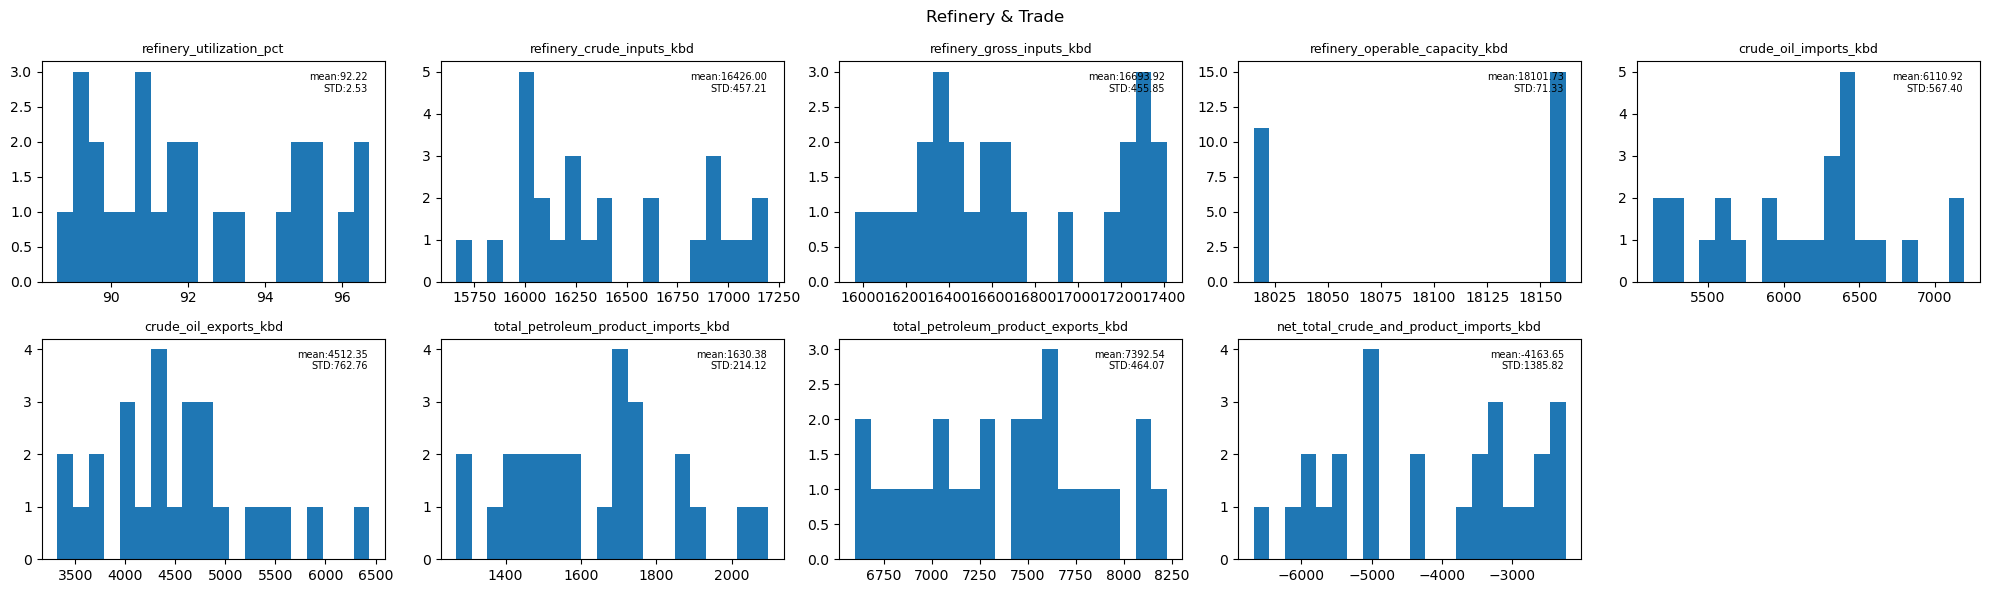

In [101]:
plot_histograms(refinery_trade, "Refinery & Trade", save_path="../charts/refinery_trade_histograms.png")

## Refinery & Trade Distributions

### `refinery_operable_capacity_kbd` — a striking near-step-function

This column shows almost all values clustered into just **two tight 
groups**: ~18,000-18,025 kbd (11 weeks) and ~18,150-18,175 kbd (the rest). 
This isn't a bimodal price shock like crude oil — operable refinery 
capacity is a physical infrastructure figure that doesn't change 
gradually; it steps up (or down) discretely when a refinery or unit comes 
online/offline. This likely reflects a real capacity change mid-period, 
not noise.

### Most other columns — noisy, roughly spread, no dramatic bimodal pattern

Unlike crude oil and gasoline prices, `refinery_utilization_pct`, 
`refinery_crude_inputs_kbd`, `refinery_gross_inputs_kbd`, 
`crude_oil_imports_kbd`, `crude_oil_exports_kbd`, and the import/export 
totals show more gradual, spread-out distributions without the same sharp 
two-cluster pattern. This makes sense — refinery operations and trade 
flows likely adjust more continuously in response to price shocks, rather 
than snapping between two discrete states the way spot prices did.

### `net_total_crude_and_product_imports_kbd` is entirely negative

Mean **-4163.65**, with values ranging roughly -7000 to -2000 — confirming 
the US was a **net exporter** throughout this period (negative net 
imports = net exports). This matches the dataset README's finding that 
"net petroleum exports roughly doubled... as the U.S. absorbed demand 
redirected away from the closed Strait of Hormuz" — the histogram shows 
this as a genuinely wide spread, consistent with exports scaling up over 
the crisis period rather than staying flat.

### Takeaway

Refinery/trade data behaves differently from price data — it reflects 
physical capacity and flow adjustments (more gradual, sometimes 
step-like) rather than the sharp two-state price shock seen in crude oil 
and gasoline. `refinery_operable_capacity_kbd`'s step pattern is worth 
flagging as a potential feature (e.g., a capacity-change indicator) if it 
corresponds to a specific, identifiable date in the crisis timeline.

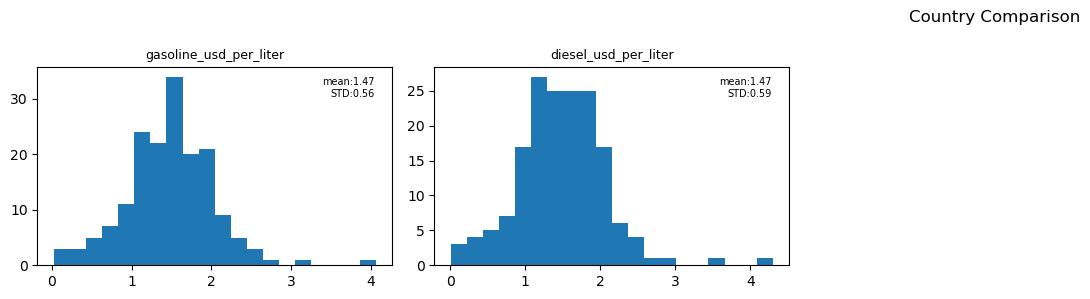

In [102]:
plot_histograms(country_comparison, "Country Comparison", save_path="../charts/country_comparison_histograms.png")


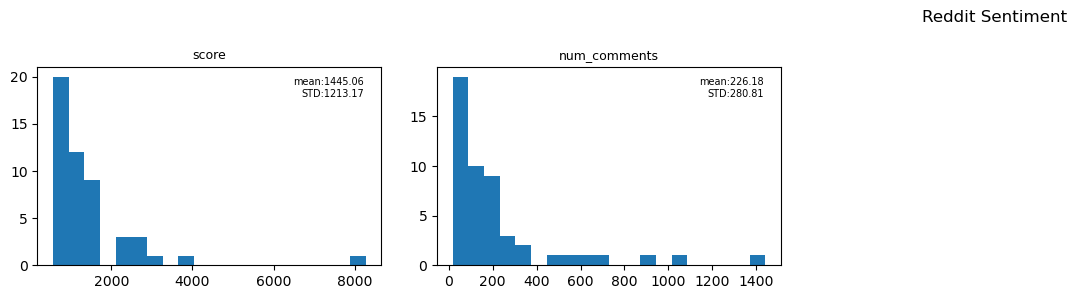

In [103]:
plot_histograms(reddit_sentiment, "Reddit Sentiment", save_path="../charts/reddit_sentiment_histograms.png")

## Country Comparison Distributions

### `gasoline_usd_per_liter` and `diesel_usd_per_liter` — both right-skewed, single main cluster

Both columns show a **normal-ish, right-skewed distribution** — most 
countries cluster around $1-2/liter for both fuels, with a long thin 
tail extending toward $4+. Mean is identical for both (**1.47**), though 
diesel has slightly higher variance (STD 0.59 vs 0.56).

The long right tail is consistent with the 5 outlier rows flagged earlier 
by the IQR check — likely countries with unusually high pump prices 
(heavy taxation, import dependency), sitting apart from the main cluster. 
Conversely, the near-zero end of the range reflects countries like Iran, 
whose heavily subsidized domestic fuel pricing (noted in the dataset 
README at $0.029/liter) sits far below the global norm.

---

## Reddit Sentiment Distributions

### Both `score` and `num_comments` are heavily right-skewed

The vast majority of posts (~20 of 50) cluster at the low end of `score` 
(under ~1000) and `num_comments` (under ~200), with a long tail of a few 
much more viral posts reaching up to 8000+ score and 1400+ comments.

This is a very typical, expected pattern for social media engagement 
data — a small number of posts go disproportionately viral while most 
get modest engagement. The high STD relative to the mean (score: mean 
1445, STD 1213 — nearly as large as the mean itself) confirms this heavy 
skew numerically, not just visually.

### Takeaway

Both datasets show classic right-skewed patterns typical of their domain 
(pricing has a natural floor near zero with occasional high outliers; 
social engagement follows a power-law-like distribution where a few 
posts dominate). For the Reddit data specifically, if sentiment/ 
engagement is used as a model feature later, the high-engagement outlier 
posts likely carry disproportionate signal about public attention to the 
crisis and shouldn't be discarded as noise.

In [104]:
crude_oil["date"] = pd.to_datetime(crude_oil["date"])
crude_oil = crude_oil.sort_values("date")
crude_oil = crude_oil.set_index("date")

In [105]:
crude_oil.head()
crude_oil.index

DatetimeIndex(['2026-01-02', '2026-01-05', '2026-01-06', '2026-01-07',
               '2026-01-08', '2026-01-09', '2026-01-12', '2026-01-13',
               '2026-01-14', '2026-01-15',
               ...
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-03'],
              dtype='datetime64[ns]', name='date', length=126, freq=None)

In [106]:
result = adfuller(crude_oil["wti_crude_close"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.3302035088860913
p-value: 0.6152434191810003


<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.2 Correlation Analysis</h3>
</div>

In [108]:
correlation , p_value = pearsonr(crude_oil["wti_crude_close"], crude_oil["brent_crude_close"])
print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.9819057893094719
P-value: 1.7732091252560057e-91


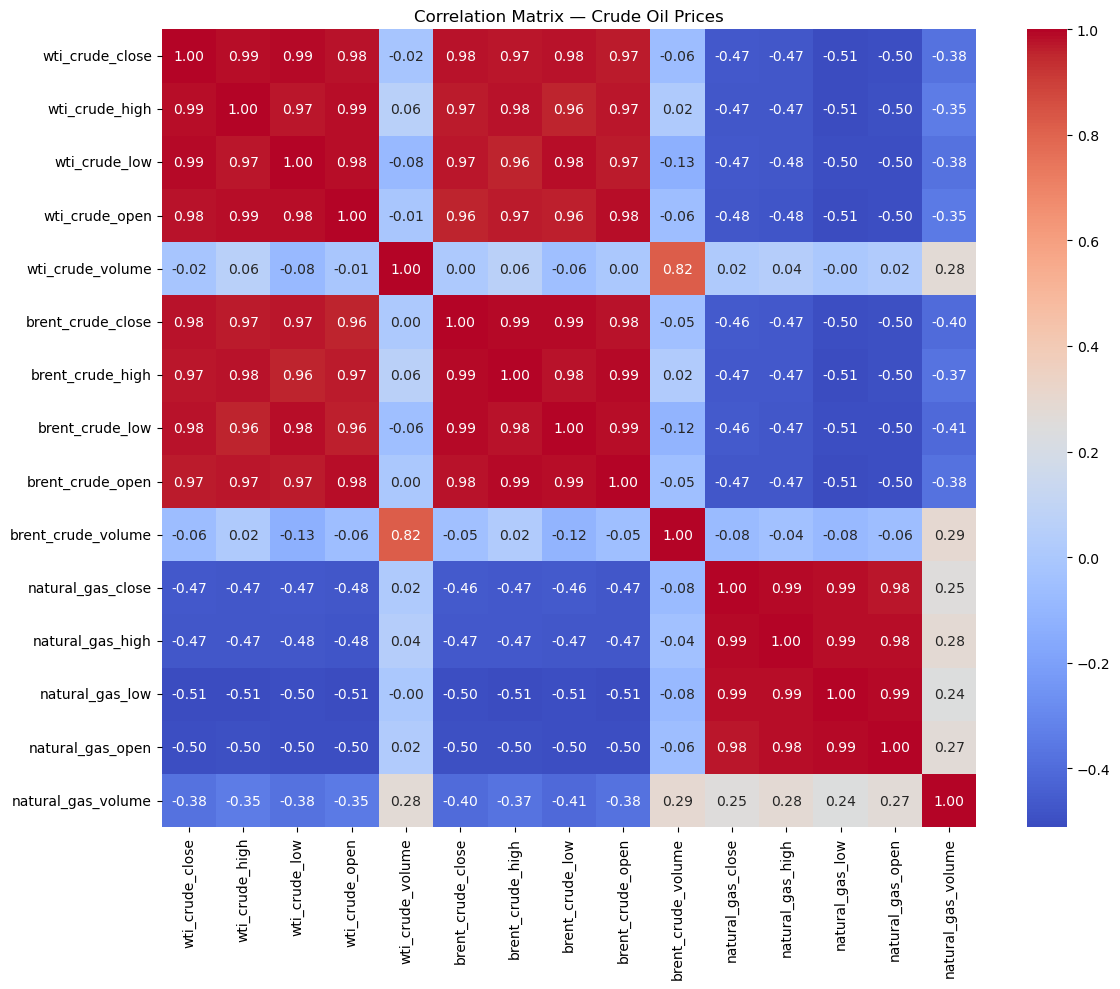

In [110]:
numeric_cols = crude_oil.select_dtypes(include="number").columns
corr_matrix = crude_oil[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Crude Oil Prices")
plt.tight_layout()

plt.savefig("../charts/crude_oil_correlation_heatmap.png", dpi=150, bbox_inches="tight")

plt.show()

## Correlation Matrix — Crude Oil Prices

### WTI and Brent — near-perfectly correlated (0.96–0.99)

Every WTI price column correlates 0.96-0.99 with every Brent price 
column, confirming the earlier `pearsonr` finding (0.98 between close 
prices) extends across open/high/low too. This is expected — both 
benchmarks reflect the same global crude oil market reacting to the same 
crisis.

**Implication for feature engineering:** WTI and Brent carry almost 
identical information. Including both as separate model features risks 
redundancy (multicollinearity) — worth considering using just one 
benchmark, or an engineered feature like their spread/difference, rather 
than all 8 columns independently.

### Natural gas moves in the OPPOSITE direction from crude oil (-0.46 to -0.51)

Natural gas prices show a **consistent negative correlation** with crude 
oil prices — around -0.47 to -0.51 across the board. This is a genuinely 
interesting finding: as crude oil prices spiked during the crisis, 
natural gas prices tended to move the *other* way. This could reflect 
substitution effects (energy consumers/markets shifting toward natural 
gas as crude became more expensive) or simply different supply dynamics, 
since natural gas wasn't directly affected by the Strait of Hormuz 
closure the way seaborne crude oil trade was.

### Volume columns behave independently from price

`wti_crude_volume` and `brent_crude_volume` show a strong correlation 
**with each other** (0.82) but **near-zero correlation with price 
columns** (mostly -0.13 to 0.06). This confirms what the earlier 
histograms suggested — trading volume follows its own pattern, largely 
decoupled from the price level itself.

### Natural gas volume is the outlier of the volume columns

Unlike WTI/Brent volume (which correlate strongly with each other), 
`natural_gas_volume` shows only weak correlation with both other volume 
columns (~0.24-0.29) and weak *positive* correlation with natural gas 
price itself (~0.25-0.28) — a different relationship pattern than crude 
oil's volume-price disconnect.

### Takeaway

Three genuinely distinct behavioral groups emerge: (1) WTI/Brent prices — 
near-identical, redundant; (2) natural gas prices — inversely related to 
crude oil, a real and useful signal; (3) trading volumes — largely 
independent of price levels. This structure should directly inform 
feature selection — reduce redundant WTI/Brent columns, but keep natural 
gas as a distinct, informative feature given its inverse relationship.

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.3 Data Visualization</h3>
</div>

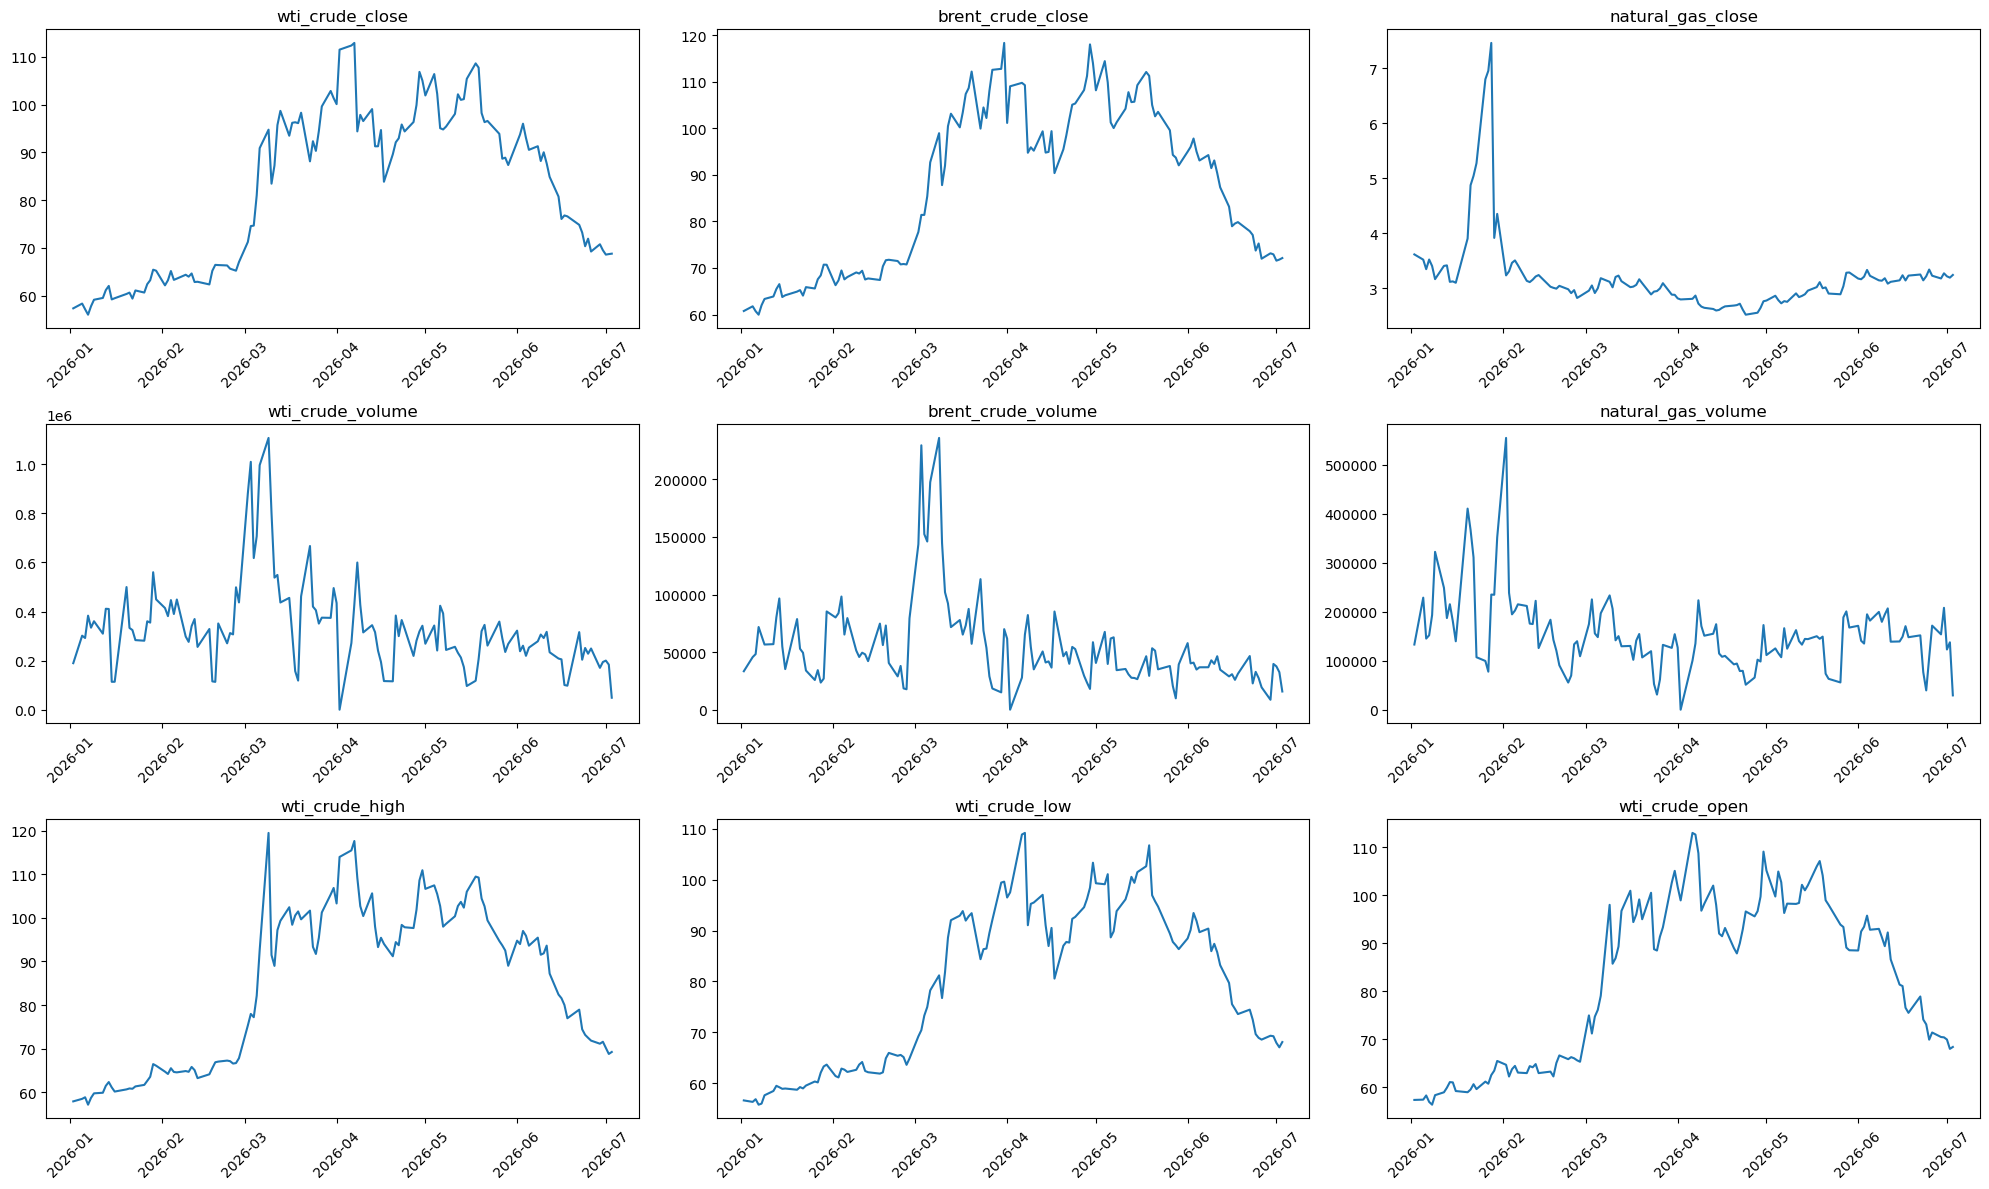

In [112]:
fig, ax = plt.subplots(3, 3, figsize=(20, 12))
ax = ax.flatten()

price_cols = ["wti_crude_close", "brent_crude_close", "natural_gas_close",
              "wti_crude_volume", "brent_crude_volume", "natural_gas_volume",
              "wti_crude_high", "wti_crude_low", "wti_crude_open"]

for i, col in enumerate(price_cols):
    ax[i].plot(crude_oil.index, crude_oil[col])
    ax[i].set_title(col)
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../charts/crude_oil_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## Crude Oil Price Time Series

### WTI and Brent — the crisis arc, clearly visible

Both `wti_crude_close` and `brent_crude_close` show the same distinct 
shape: a stable, low baseline through January-February (~$56-70), a sharp 
climb starting early March, peaking around early-to-mid April (WTI 
~$113, Brent ~$118), a volatile plateau through May, then a steady 
decline back toward $68-72 by late June/early July. This is the crisis 
arc directly visualized — the bimodal histogram from earlier is now 
explained as "before the spike" and "during/after the spike," not two 
unrelated clusters.

### Natural gas — a sharp, SHORT spike, very different shape from crude oil

`natural_gas_close` shows something structurally different — a **very 
brief, sharp spike** in late January (jumping from ~$3.5 to ~$7.4), then 
a fast decline back to baseline (~$3) by February, staying flat for the 
rest of the period. This confirms the earlier negative-correlation 
finding — natural gas reacted early and briefly, while crude oil's shock 
was slower-building and much longer-lasting. These are genuinely 
different crisis dynamics, not the same event playing out on two fuels.

### Volume — spikes align with price volatility, not price level

`wti_crude_volume` and `brent_crude_volume` both show a clear spike 
around early-to-mid March — right as prices began their sharp initial 
climb — then return to noisy but lower levels for the rest of the 
period, even while prices stayed elevated through April-May. This 
confirms the earlier correlation finding: volume tracks *volatility/
uncertainty* around the initial shock, not the price level itself.

### Takeaway

The time series confirms and explains every earlier statistical finding: 
the bimodal histograms, the WTI-Brent near-perfect correlation, the 
negative natural-gas correlation, and the volume-price disconnect all 
make direct visual sense once seen over time. This strongly suggests 
**the exact date of the price peak (~early April) and natural gas's 
distinct late-January spike** should both be explicitly captured as 
features (e.g., days-since-crisis-start, days-since-peak) for the 
forecasting model, rather than relying on raw price levels alone to 
capture this structure.